# Notebook 10b: Multi-Seed Ablation - Direct Transfer Statistical Power

Sequential Transfer Learning for Medicinal Plant Identification
Student: Hari (3146279) | BSc Software Engineering | University of Stirling

Re-run the direct transfer experiment (ImageNet -> Dataset 5) with 5 different
random seeds to check whether the gap between direct and sequential transfer
is statistically meaningful. Seeds: 42, 123, 456, 789, 2024.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU!")

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: /physical_device:GPU:0


In [2]:
# ── Configuration ──
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MAX_EPOCHS = 25
LR = 5e-5
UNFREEZE_LAST = 20  # Same as Phase 3b and original ablation

SEEDS = [42, 123, 456, 789, 2024]

DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "multiseed_ablation_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

DROP_CLASSES = ['Trifolium Repens', 'Trifolium_Repens',
                'Ziziphus mauritiana', 'Ziziphus_mauritiana']

print(f"Seeds: {SEEDS}")
print(f"Results dir: {RESULTS_DIR}")

Seeds: [42, 123, 456, 789, 2024]
Results dir: /content/drive/MyDrive/MedicinalPlant_Dissertation/multiseed_ablation_results


## 1. Find and Prepare Dataset 5 (18 classes)

In [ ]:
import time as _time

def find_image_directory(base_dir):
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(sample_dir)):
                return root
    return None

def robust_copytree(src, dst, max_retries=3):
    """Copy with retry for Drive connectivity issues."""
    os.makedirs(dst, exist_ok=True)
    for item in os.listdir(src):
        s = os.path.join(src, item)
        d = os.path.join(dst, item)
        if os.path.isdir(s):
            robust_copytree(s, d, max_retries)
        else:
            for attempt in range(max_retries):
                try:
                    shutil.copy2(s, d)
                    break
                except (OSError, IOError) as e:
                    if attempt < max_retries - 1:
                        print(f"  Retry {attempt+1}/{max_retries} for {os.path.basename(s)}: {e}")
                        _time.sleep(2 ** attempt)
                    else:
                        raise

# Find Dataset 5
dataset5_path = None
for p in [os.path.join(DATA_DIR, "dataset5"),
          os.path.join(DATA_DIR, "Dataset 5"),
          os.path.join(DATA_DIR, "SIMPD")]:
    if os.path.exists(p):
        found = find_image_directory(p)
        if found:
            dataset5_path = found
            break

if dataset5_path is None:
    raise FileNotFoundError("Dataset 5 not found!")
print(f"Dataset 5 found: {dataset5_path}")

# Filter to 18 classes
all_classes = sorted([
    d for d in os.listdir(dataset5_path)
    if os.path.isdir(os.path.join(dataset5_path, d)) and not d.startswith('.')
])
keep_classes = [c for c in all_classes if c not in DROP_CLASSES]

filtered_d5 = "/content/multiseed_dataset5"
if os.path.exists(filtered_d5):
    shutil.rmtree(filtered_d5)
os.makedirs(filtered_d5)

print(f"Copying {len(keep_classes)} classes...")
for i, c in enumerate(keep_classes):
    robust_copytree(os.path.join(dataset5_path, c), os.path.join(filtered_d5, c))
    print(f"  [{i+1}/{len(keep_classes)}] {c}")

NUM_CLASSES = len(keep_classes)
class_names = sorted(os.listdir(filtered_d5))
total_images = sum(len(os.listdir(os.path.join(filtered_d5, c))) for c in class_names)
print(f"\nFiltered dataset: {NUM_CLASSES} classes, {total_images} images at {filtered_d5}")

Dataset 5 found: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset5/SIMPD V1 South Indian Medicinal Plants dataset (Version 1)
Copying 18 classes...
  [1/18] Abutilon Indicum
  [2/18] Aloe barbadensis miller
  [3/18] Calotropis gigantea
  [4/18] Canna indica
  [5/18] Cissus quadrangularis
  [6/18] Curcuma longa
  [7/18] Eclipta prostrate
  [8/18] Eichhornia Crassipes
  [9/18] Hibiscus Rosasinensis
  [10/18] Ixora coccinea
  [11/18] Justica adhatoda
  [12/18] Murraya koenigii
  [13/18] Ocimum tenuiflorum
  [14/18] Ouretlanata
  [15/18] Phyllanthus amarus
  [16/18] Ricinus communis
  [17/18] Senna Atriculata
  [18/18] Sesbania grandiflora

Filtered dataset: 18 classes, 2313 images at /content/multiseed_dataset5


## 2. Define Model Builder and Training Loop

In [4]:
def build_direct_model(num_classes):
    """Build ResNet50 model — same architecture as NB08 Experiment 1."""
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = True
    for layer in base.layers[:-UNFREEZE_LAST]:
        layer.trainable = False

    data_aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name='augmentation')

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_aug(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def run_single_seed(seed, filtered_path, num_classes):
    """Run one complete direct transfer experiment with a given seed."""
    print(f"\n{'='*60}")
    print(f"SEED {seed}")
    print(f"{'='*60}")

    # Set all random seeds
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Load data with this seed's split
    # NOTE: Using seed=42 for the data split to keep the SAME validation set
    # across all runs. The seed parameter here controls model initialisation
    # and training stochasticity (dropout, augmentation, batch shuffling).
    train_ds = tf.keras.utils.image_dataset_from_directory(
        filtered_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        seed=42, label_mode='categorical', validation_split=0.2, subset='training'
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        filtered_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        seed=42, label_mode='categorical', validation_split=0.2, subset='validation'
    )

    norm = layers.Rescaling(1./255)
    train_ds = train_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

    # Clear session for clean model init
    keras.backend.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Build and train
    model = build_direct_model(num_classes)

    model_path = os.path.join(RESULTS_DIR, f'direct_seed{seed}_best.keras')
    callbacks = [
        ModelCheckpoint(model_path, monitor='val_loss', mode='min',
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                          patience=3, verbose=1),
    ]

    start_time = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=MAX_EPOCHS, callbacks=callbacks, verbose=1
    )
    elapsed = time.time() - start_time

    # Evaluate at best val_loss epoch (matches EarlyStopping restore_best_weights)
    results = model.evaluate(val_ds, verbose=0)
    loss, accuracy = results[0], results[1]

    print(f"\n--- Seed {seed} Results ---")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Loss: {loss:.4f}")
    print(f"Time: {elapsed/60:.1f} min")

    # Save history
    hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(os.path.join(RESULTS_DIR, f'direct_seed{seed}_history.json'), 'w') as f:
        json.dump(hist_dict, f, indent=2)

    # Clean up model to free GPU memory
    del model
    keras.backend.clear_session()

    return {
        'seed': seed,
        'accuracy': float(accuracy),
        'loss': float(loss),
        'epochs_trained': len(history.history['loss']),
        'time_minutes': round(elapsed / 60, 1)
    }

print("Model builder and training loop defined.")

Model builder and training loop defined.


## 3. Run All Seeds

This will take 3-5 hours. Each run trains for up to 25 epochs.
Results are saved after each seed, so you can safely restart and skip completed seeds.

In [ ]:
all_results = []

# Check for already-completed seeds (resume support)
summary_path = os.path.join(RESULTS_DIR, 'multiseed_summary.json')
completed_seeds = set()
if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        prev = json.load(f)
    all_results = prev.get('per_seed', [])
    completed_seeds = {r['seed'] for r in all_results}
    print(f"Resuming -- already completed seeds: {completed_seeds}")

for seed in SEEDS:
    if seed in completed_seeds:
        print(f"\nSkipping seed {seed} (already completed)")
        continue

    result = run_single_seed(seed, filtered_d5, NUM_CLASSES)
    all_results.append(result)

    # Save intermediate summary after each seed
    accs = [r['accuracy'] for r in all_results]
    intermediate = {
        'per_seed': all_results,
        'completed': len(all_results),
        'mean_accuracy': float(np.mean(accs)),
        'std_accuracy': float(np.std(accs)),
    }
    with open(summary_path, 'w') as f:
        json.dump(intermediate, f, indent=2)
    print(f"\nSaved intermediate results ({len(all_results)}/{len(SEEDS)} seeds done)")

print(f"\nAll {len(SEEDS)} seeds complete.")


SEED 42
Found 2313 files belonging to 18 classes.
Using 1851 files for training.
Found 2313 files belonging to 18 classes.
Using 462 files for validation.
Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 436ms/step - accuracy: 0.0912 - loss: 3.6458 - val_accuracy: 0.1688 - val_loss: 3.0023 - learning_rate: 5.0000e-05
--- Seed 42 Results ---
Accuracy: 71.65%
Loss: 1.1483
Time: 8.4 min

Saved intermediate results (1/5 seeds done)

SEED 123
--- Seed 123 Results ---
Accuracy: 66.02%
Loss: 1.3206
Time: 8.4 min

Saved intermediate results (2/5 seeds done)

SEED 456
--- Seed 456 Results ---
Accuracy: 67.97%
Loss: 1.2441
Time: 8.7 min

Saved intermediate results (3/5 seeds done)

SEED 789
--- Seed 789 Results ---
Accuracy: 70.56%
Loss: 1.1652
Time: 8.2 min

Saved intermediate results (4/5 seeds done)

SEED 2024
--- Seed 2024 Results ---
Accuracy: 73.81%
Loss: 1.0584
Time: 8.1 min

Saved intermediate results (5/5 seeds done)

All 5 seeds complete.


## 4. Analyse Results

In [ ]:
# Load results (works even if you restart runtime)
with open(os.path.join(RESULTS_DIR, 'multiseed_summary.json'), 'r') as f:
    summary = json.load(f)

all_results = summary['per_seed']
accs = [r['accuracy'] * 100 for r in all_results]
mean_acc = np.mean(accs)
std_acc = np.std(accs)
min_acc = np.min(accs)
max_acc = np.max(accs)

print(f"{'='*60}")
print(f"MULTI-SEED DIRECT TRANSFER RESULTS")
print(f"{'='*60}")
print(f"\nSeeds: {[r['seed'] for r in all_results]}")
print(f"\nPer-seed accuracies:")
for r in all_results:
    print(f"  Seed {r['seed']:>4d}: {r['accuracy']*100:.2f}% ({r['epochs_trained']} epochs, {r['time_minutes']} min)")

print(f"\n--- Statistical Summary ---")
print(f"Mean:  {mean_acc:.2f}%")
print(f"Std:   {std_acc:.2f}%")
print(f"Range: {min_acc:.2f}% - {max_acc:.2f}%")
print(f"95% CI: {mean_acc:.2f} +/- {1.96*std_acc:.2f}%")
print(f"        [{mean_acc - 1.96*std_acc:.2f}%, {mean_acc + 1.96*std_acc:.2f}%]")

# Compare with sequential (18-class fair comparison from NB10a)
seq_acc = 71.43
print(f"\n--- Comparison with Sequential Pipeline ---")
print(f"Sequential (18 classes): {seq_acc:.2f}%")
print(f"Direct mean (18 classes): {mean_acc:.2f} +/- {std_acc:.2f}%")
print(f"Gap: {mean_acc - seq_acc:.2f} +/- {std_acc:.2f} pp")

if std_acc > abs(mean_acc - seq_acc) / 2:
    print(f"\nThe std ({std_acc:.2f}) is large relative to the gap ({mean_acc - seq_acc:.2f} pp).")
    print(f"The difference may not be statistically significant.")
else:
    print(f"\nThe std ({std_acc:.2f}) is small relative to the gap ({mean_acc - seq_acc:.2f} pp).")
    print(f"The difference appears statistically meaningful.")

MULTI-SEED DIRECT TRANSFER RESULTS

Seeds: [42, 123, 456, 789, 2024]

Per-seed accuracies:
  Seed   42: 71.65% (25 epochs, 8.4 min)
  Seed  123: 66.02% (25 epochs, 8.4 min)
  Seed  456: 67.97% (25 epochs, 8.7 min)
  Seed  789: 70.56% (25 epochs, 8.2 min)
  Seed 2024: 73.81% (25 epochs, 8.1 min)

--- Statistical Summary ---
Mean:  70.00%
Std:   2.74%
Range: 66.02% - 73.81%
95% CI: 70.00 +/- 5.37%
        [64.63%, 75.37%]

--- Comparison with Sequential Pipeline ---
Sequential (18 classes): 71.43%
Direct mean (18 classes): 70.00 +/- 2.74%
Gap: -1.43 +/- 2.74 pp

The std (2.74) is large relative to the gap (-1.43 pp).
The difference may not be statistically significant.


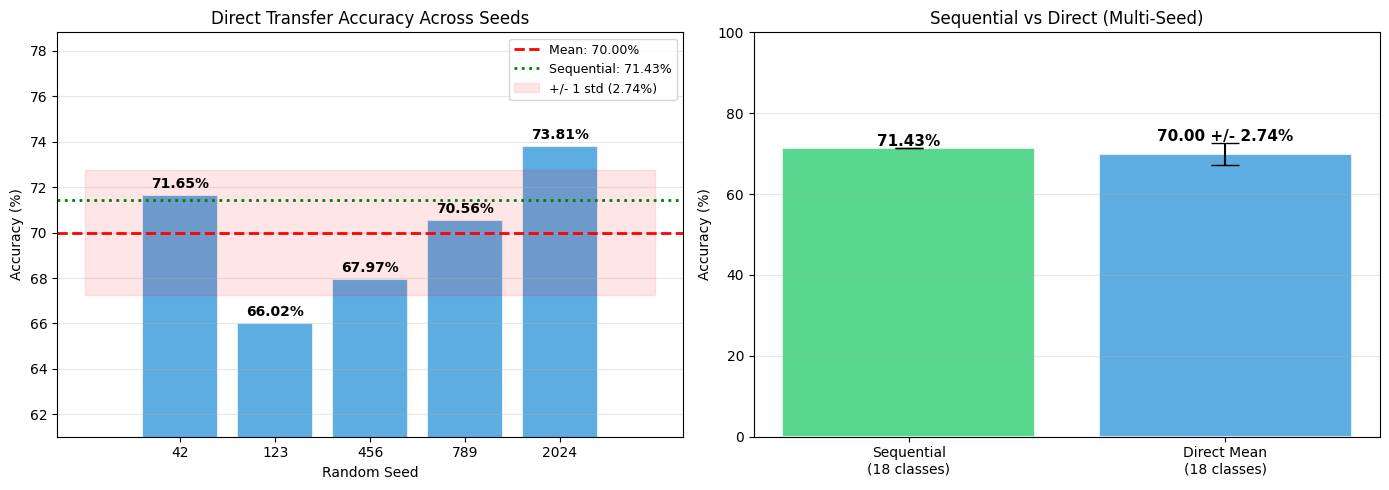


Plot saved to /content/drive/MyDrive/MedicinalPlant_Dissertation/multiseed_ablation_results/multiseed_comparison.png


In [7]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-seed accuracy bar chart
ax = axes[0]
seeds_str = [str(r['seed']) for r in all_results]
ax.bar(seeds_str, accs, color='#3498db', alpha=0.8, edgecolor='white', linewidth=1.5)
ax.axhline(y=mean_acc, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_acc:.2f}%')
ax.axhline(y=seq_acc, color='green', linestyle=':', linewidth=2, label=f'Sequential: {seq_acc:.2f}%')
ax.fill_between(range(-1, len(seeds_str)+1), mean_acc - std_acc, mean_acc + std_acc,
                color='red', alpha=0.1, label=f'+/- 1 std ({std_acc:.2f}%)')
for i, acc in enumerate(accs):
    ax.text(i, acc + 0.3, f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Random Seed')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Direct Transfer Accuracy Across Seeds')
ax.set_ylim(min(min_acc, seq_acc) - 5, max_acc + 5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Right: comparison with sequential (both on 18 classes)
ax = axes[1]
strategies = ['Sequential\n(18 classes)', 'Direct Mean\n(18 classes)']
vals = [seq_acc, mean_acc]
errs = [0, std_acc]  # no error bar for sequential (single run)
colors = ['#2ecc71', '#3498db']
bars = ax.bar(strategies, vals, yerr=errs, capsize=10, color=colors, alpha=0.8,
              edgecolor='white', linewidth=1.5)
for bar, val, err in zip(bars, vals, errs):
    label = f'{val:.2f}%' if err == 0 else f'{val:.2f} +/- {err:.2f}%'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.5,
            label, ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Sequential vs Direct (Multi-Seed)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'multiseed_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to {RESULTS_DIR}/multiseed_comparison.png")

In [ ]:
# Save final summary
final_summary = {
    'experiment': 'Multi-seed direct transfer (ImageNet -> Dataset 5, 18 classes)',
    'seeds': [r['seed'] for r in all_results],
    'per_seed': all_results,
    'statistics': {
        'mean_accuracy': round(float(mean_acc), 2),
        'std_accuracy': round(float(std_acc), 2),
        'min_accuracy': round(float(min_acc), 2),
        'max_accuracy': round(float(max_acc), 2),
        'ci_95_lower': round(float(mean_acc - 1.96*std_acc), 2),
        'ci_95_upper': round(float(mean_acc + 1.96*std_acc), 2),
    },
    'comparison': {
        'sequential_18class': seq_acc,
        'direct_mean_18class': round(float(mean_acc), 2),
        'gap_pp': round(float(mean_acc - seq_acc), 2),
        'gap_significant': bool(std_acc < abs(mean_acc - seq_acc) / 2)
    },
    'hyperparameters': {
        'img_size': list(IMG_SIZE),
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'learning_rate': LR,
        'unfreeze_last': UNFREEZE_LAST,
        'data_split_seed': 42
    }
}

with open(os.path.join(RESULTS_DIR, 'multiseed_summary.json'), 'w') as f:
    json.dump(final_summary, f, indent=2)

print(f"Final summary saved to: {RESULTS_DIR}/multiseed_summary.json")
print(f"\nDirect transfer: {mean_acc:.2f} +/- {std_acc:.2f}% (mean +/- std, n={len(SEEDS)} seeds)")
print(f"95% CI: [{mean_acc - 1.96*std_acc:.2f}%, {mean_acc + 1.96*std_acc:.2f}%]")

Final summary saved to: /content/drive/MyDrive/MedicinalPlant_Dissertation/multiseed_ablation_results/multiseed_summary.json

Direct transfer: 70.00 +/- 2.74% (mean +/- std, n=5 seeds)
95% CI: [64.63%, 75.37%]
